In [1]:
# Create Dockerfile and docker-compose.yml files in the repo root.
dockerfile = r'''
FROM python:3.10-slim

WORKDIR /app

# System deps
RUN apt-get update && apt-get install -y build-essential wget git && rm -rf /var/lib/apt/lists/*

# Copy requirements if present; fallback to pip install later
COPY requirements.txt /app/requirements.txt
RUN pip install --no-cache-dir -r /app/requirements.txt || true

COPY . /app

EXPOSE 5000

CMD ["python", "app.py"]
'''.strip()

compose = r'''
version: "3.8"
services:
  rag_app:
    build: .
    container_name: rag_app
    ports:
      - "5000:5000"
    volumes:
      - .:/app
    environment:
      - FLASK_ENV=development
'''.strip()

with open("Dockerfile","w",encoding="utf-8") as f:
    f.write(dockerfile)
with open("docker-compose.yml","w",encoding="utf-8") as f:
    f.write(compose)

print("Wrote Dockerfile and docker-compose.yml. Add your requirements.txt and then run `docker-compose up --build`.")


Wrote Dockerfile and docker-compose.yml. Add your requirements.txt and then run `docker-compose up --build`.


In [4]:
# Imports
import os, json, glob, time, math
from urllib.parse import urljoin, urlparse
import requests
from bs4 import BeautifulSoup
from markdownify import markdownify
from tqdm import tqdm
import nltk
nltk.download('punkt', quiet=True)

# Directories
BASE_URL = "https://pantelis.github.io/courses/ai/"
RAW_DIR = "data/raw/course_site/"
PAGE_DIR = os.path.join(RAW_DIR, "pages")
ASSET_DIR = os.path.join(RAW_DIR, "assets")

TEXT_DIR = "data/processed/text"
CHUNK_DIR = "data/processed/chunks"
DB_DIR = "data/vector_db"

os.makedirs(PAGE_DIR, exist_ok=True)
os.makedirs(ASSET_DIR, exist_ok=True)
os.makedirs(TEXT_DIR, exist_ok=True)
os.makedirs(CHUNK_DIR, exist_ok=True)
os.makedirs(DB_DIR, exist_ok=True)

print("Directories ready.")


Directories ready.


In [14]:
visited = set()

def is_internal_link(url):
    """Allow crawling ANY page on pantelis.github.io"""
    parsed = urlparse(url)
    return "pantelis.github.io" in parsed.netloc

def scrape_page(url):
    url = url.rstrip("/")  # normalize
    
    if url in visited:
        return []
    visited.add(url)

    print(f"[scrape] fetching {url}")

    try:
        response = requests.get(url, timeout=10)
        if response.status_code != 200:
            print(f"[scrape] failed: {url}")
            return []
    except Exception as e:
        print(f"[scrape] request error: {e}")
        return []

    soup = BeautifulSoup(response.text, "html.parser")

    # Create safe filename from URL
    parsed_url = urlparse(url)
    path = parsed_url.path
    
    # Handle empty path
    if not path or path == "/":
        path = "/index.html"
    
    # Remove leading/trailing slashes
    path = path.strip("/")
    
    if not path:  # If path is empty after stripping (e.g., root URL)
        filename = "index.html"
    else:
        # Replace / with _ and ensure .html extension
        filename = path.replace("/", "_")
        if not filename.endswith(".html") and not filename.endswith(".txt") and not filename.endswith(".pdf") and not filename.endswith(".ipynb"):
            filename += ".html"
    
    # Clean filename of problematic characters
    filename = "".join(c for c in filename if c.isalnum() or c in "._-")
    
    # Construct paths
    html_path = os.path.join(PAGE_DIR, filename)
    
    # Create text filename
    text_filename = filename
    if text_filename.endswith(".html"):
        text_filename = text_filename[:-5] + ".txt"
    elif text_filename.endswith(".pdf"):
        text_filename = text_filename[:-4] + ".txt"
    elif text_filename.endswith(".ipynb"):
        text_filename = text_filename[:-6] + ".txt"
    else:
        text_filename += ".txt"
    
    text_path = os.path.join(PAGE_DIR, text_filename)

    # Ensure directory exists
    os.makedirs(PAGE_DIR, exist_ok=True)

    # Save HTML
    try:
        with open(html_path, "w", encoding="utf-8") as f:
            f.write(response.text)
    except Exception as e:
        print(f"[scrape] error saving HTML {html_path}: {e}")
        # Try to create parent directory
        os.makedirs(os.path.dirname(html_path), exist_ok=True)
        try:
            with open(html_path, "w", encoding="utf-8") as f:
                f.write(response.text)
        except Exception as e2:
            print(f"[scrape] retry failed: {e2}")
            return []

    # Extract and save text (skip for non-HTML files like PDFs)
    if filename.endswith(".html"):
        try:
            text = soup.get_text(separator="\n", strip=True)
            with open(text_path, "w", encoding="utf-8") as f:
                f.write(text)
        except Exception as e:
            print(f"[scrape] error saving text {text_path}: {e}")
    else:
        print(f"[scrape] skipping text extraction for non-HTML file: {filename}")

    # Collect links (only from HTML files)
    new_links = []
    if filename.endswith(".html"):
        for a in soup.find_all("a", href=True):
            # Clean fragments (#section)
            href = a["href"].split("#")[0]

            # Skip empty/anchor links
            if href.strip() == "":
                continue

            # Skip mailto:, javascript:, etc.
            if href.lower().startswith(('mailto:', 'javascript:', 'tel:')):
                continue

            # Join with base URL
            try:
                full_url = urljoin(url, href).rstrip("/")
            except:
                continue

            # Skip external links
            if not is_internal_link(full_url):
                continue

            if full_url not in visited:
                new_links.append(full_url)

    return new_links

'''def scrape_course_site():
    print("[scrape] starting course site scrape...")
    to_visit = [BASE_URL]
    while to_visit:
        url = to_visit.pop()
        try:
            new_links = scrape_page(url)
            to_visit.extend(new_links)
        except Exception as e:
            print("[scrape] error", e)
    print(f"[scrape] done. Total pages: {len(visited)}")'''
def scrape_course_site():
    # Ensure all directories exist before starting
    os.makedirs(PAGE_DIR, exist_ok=True)
    os.makedirs(ASSET_DIR, exist_ok=True)
    os.makedirs(TEXT_DIR, exist_ok=True)
    os.makedirs(CHUNK_DIR, exist_ok=True)
    os.makedirs(DB_DIR, exist_ok=True)
    
    print("[scrape] starting course site scrape...")
    to_visit = [BASE_URL]
    
    while to_visit:
        url = to_visit.pop()
        try:
            new_links = scrape_page(url)
            to_visit.extend(new_links)
        except Exception as e:
            print(f"[scrape] error processing {url}: {e}")
    
    print(f"[scrape] done. Total pages: {len(visited)}")

# Run it
scrape_course_site()


[scrape] starting course site scrape...
[scrape] fetching https://pantelis.github.io/courses/ai
[scrape] fetching https://pantelis.github.io/courses/ai/online.html
[scrape] fetching https://pantelis.github.io/aiml-common/projects/nlp/ai-tutor/index.html
[scrape] fetching https://pantelis.github.io/aiml-common/assignments/main/ai-fall-2025/assignment-4.html
[scrape] fetching https://pantelis.github.io/aiml-common/assignments/main/ai-fall-2025/assignment-3.html
[scrape] fetching https://pantelis.github.io/aiml-common/assignments/main/ai-fall-2025/assignment-2.html
[scrape] fetching https://pantelis.github.io/aiml-common/assignments/main/ai-fall-2025/assignment-1-grad.html
[scrape] fetching https://pantelis.github.io/aiml-common/assignments/main/ai-fall-2025/assignment-1-undergrad.html
[scrape] fetching https://pantelis.github.io/aiml-common/lectures/python/index.html
[scrape] fetching https://pantelis.github.io/aiml-common/resources/environment/index.html
[scrape] fetching https://pantel

In [15]:
'''txt_files = sorted(glob.glob(os.path.join(PAGE_DIR,"*.txt")))
print("Scraped pages:", len(txt_files))
for p in txt_files:
    print(" -", os.path.basename(p))
# show a sample
if txt_files:
    print("\nSample text (first 400 chars):\n")
    print(open(txt_files[0],encoding="utf-8").read()[:400])'''

txt_files = sorted(glob.glob(os.path.join(PAGE_DIR, "**", "*.txt"), recursive=True))

print("Scraped pages:", len(txt_files))
for p in txt_files:
    print(" -", os.path.basename(p))

# Show sample
if txt_files:
    print("\nSample text (first 400 chars):\n")
    with open(txt_files[0], encoding="utf-8") as f:
        print(f.read()[:400])



Scraped pages: 245
 - about.txt
 - aiml-common_assignments_main_ai-fall-2025_assignment-1-grad.txt
 - aiml-common_assignments_main_ai-fall-2025_assignment-1-undergrad.txt
 - aiml-common_assignments_main_ai-fall-2025_assignment-2.txt
 - aiml-common_assignments_main_ai-fall-2025_assignment-3.txt
 - aiml-common_assignments_main_ai-fall-2025_assignment-4.txt
 - aiml-common_assignments_main_cv-fall-2025_assignment-1.txt
 - aiml-common_assignments_main_cv-fall-2025_assignment-2.txt
 - aiml-common_assignments_main_cv-fall-2025_assignment-3.txt
 - aiml-common_assignments_main_cv-fall-2025_assignment-4.txt
 - aiml-common_assignments_main_cv-fall-2025_assignment-5.txt
 - aiml-common_assignments_main_robotics-fall-2025_assignment-1.txt
 - aiml-common_assignments_main_robotics-fall-2025_assignment-2.txt
 - aiml-common_assignments_main_robotics-fall-2025_assignment-3.txt
 - aiml-common_assignments_topics_ROS_object-detection_index-preview.txt
 - aiml-common_assignments_topics_ROS_setup_index.embed-

In [16]:
def load_all_text():
    txt_files = glob.glob(os.path.join(PAGE_DIR,"*.txt"))
    combined = []
    for fpath in txt_files:
        with open(fpath, "r", encoding="utf-8") as f:
            combined.append(f.read())
    all_text = "\n\n".join(combined)
    with open(os.path.join(TEXT_DIR, "full.txt"), "w", encoding="utf-8") as f:
        f.write(all_text)
    return all_text

def chunk_text(text, size=1200):
    chunks = []
    words = text.split()
    current = []
    for w in words:
        current.append(w)
        if len(current) >= size:
            chunks.append(" ".join(current))
            current = []
    if current:
        chunks.append(" ".join(current))
    # save chunks
    for i, c in enumerate(chunks):
        with open(os.path.join(CHUNK_DIR, f"chunk_{i}.txt"), "w", encoding="utf-8") as f:
            f.write(c)
    return chunks

print("[pipeline] combining text")
all_text = load_all_text()
print("[pipeline] chunking text")
chunks = chunk_text(all_text)
print(f"[pipeline] produced {len(chunks)} chunks")


[pipeline] combining text
[pipeline] chunking text
[pipeline] produced 392 chunks


In [ ]:
# Build vector DB using Ollama embeddings (keeps your embed_ollama)
try:
    from ollama import Client as OllamaClient
    # ========== ADD THIS AT THE TOP OF CELL 17 ==========
    import requests

    # Force the correct Ollama URL - ADD THIS LINE
    OLLAMA_BASE_URL = "http://127.0.0.1:11434"
    print(f"Using Ollama at: {OLLAMA_BASE_URL}")

    # Test connection first
    print("Testing Ollama connection...")
    try:
        response = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=10)
        if response.status_code == 200:
            print(f"✓ Ollama is running at {OLLAMA_BASE_URL}")
        else:
            print(f"✗ Ollama responded with status {response.status_code}")
    except Exception as e:
        print(f"✗ Cannot connect to Ollama at {OLLAMA_BASE_URL}: {e}")
        print("Make sure 'ollama serve' is running in another terminal!")
        # Don't exit, but you'll know there's an issue

    # ========== END OF ADDED CODE ==========
    ollama_client = OllamaClient()  # connects to http://localhost:11434
    def embed_ollama(text):
        """Fixed embedding function using direct HTTP requests"""
        try:
            # Truncate very long text (Ollama has limits)
            if len(text) > 8000:
                text = text[:8000] + " [truncated]"
            
            # Direct HTTP request to Ollama
            response = requests.post(
                f"{OLLAMA_BASE_URL}/api/embeddings",
                json={
                    "model": "nomic-embed-text",
                    "prompt": text
                },
                timeout=60  # Longer timeout
            )
            
            if response.status_code == 200:
                return response.json()["embedding"]
            else:
                raise Exception(f"Ollama returned status {response.status_code}: {response.text[:200]}")
                
        except Exception as e:
            print(f"Embedding error: {e}")
            raise
except Exception as e:
    # fallback to CLI wrapper
    import subprocess, shlex, tempfile
    print("ollama python client not available, will attempt CLI fallback (requires 'ollama' in PATH).")
    def embed_ollama(text):
        try:
            # use ollama CLI embed if available: `ollama embed MODEL --json ...` (older/newer CLI variants differ)
            # We'll try CLI run with small wrapper returning JSON (best-effort)
            proc = subprocess.run(["ollama", "embed", "nomic-embed-text", "--json"], input=text.encode("utf-8"),
                                  capture_output=True, timeout=30)
            if proc.returncode != 0:
                raise RuntimeError(proc.stderr.decode())
            j = json.loads(proc.stdout.decode())
            return j.get("embedding") or j
        except Exception as e:
            raise RuntimeError(f"Ollama embed CLI failed: {e}")

# Create Chroma collection and insert
import chromadb
from chromadb.config import Settings

client_db = chromadb.PersistentClient(path=DB_DIR)
# Use get_or_create for idempotency
try:
    collection = client_db.get_collection("ai_course")
    print("[db] using existing collection 'ai_course'")
except Exception:
    collection = client_db.create_collection("ai_course")
    print("[db] created collection 'ai_course'")

import time

print(f"[db] embedding and inserting {len(chunks)} chunks (this may take a while)...")

success_count = 0
failed_chunks = []

for i, chunk in enumerate(tqdm(chunks)):
    max_retries = 3
    for attempt in range(max_retries):
        try:
            # Small delay between retries
            if attempt > 0:
                time.sleep(2)
                print(f"Retry {attempt} for chunk {i}")
            
            emb = embed_ollama(chunk)
            
            # Handle different response formats
            if isinstance(emb, dict) and "embedding" in emb:
                emb = emb["embedding"]
            
            collection.add(
                ids=[f"chunk-{i}"], 
                embeddings=[emb], 
                documents=[chunk], 
                metadatas=[{"source":"course_site"}]
            )
            success_count += 1
            
            # Small delay every 5 chunks to avoid overwhelming Ollama
            if i % 5 == 0:
                time.sleep(0.2)
            
            break  # Success, exit retry loop
            
        except Exception as e:
            if attempt == max_retries - 1:  # Last retry failed
                print(f"[db] embed/add failed for chunk {i} after {max_retries} attempts: {e}")
                failed_chunks.append(i)
            continue

print(f"[db] Successfully embedded {success_count}/{len(chunks)} chunks")
if failed_chunks:
    print(f"[db] Failed chunks: {failed_chunks}")
print("[db] vector database build process finished.")
print("[db] vector database build process finished.")


[db] using existing collection 'ai_course'
[db] embedding and inserting 392 chunks (this may take a while)...


100%|██████████| 392/392 [01:20<00:00,  4.87it/s]

[db] vector database build process finished.


In [ ]:
# RAG functions (kept from your rag_pipeline)
from langchain_ollama import OllamaEmbeddings
import subprocess

# Use same embedding model for queries
'''embedder = OllamaEmbeddings(model="nomic-embed-text")
def embed_query(text: str):
    try:
        return embedder.embed_query(text)
    except Exception:
        # fallback to embed_ollama function above:
        return embed_ollama(text)'''

# Use the same embed_ollama function for queries too
def embed_query(text: str):
    return embed_ollama(text)

def load_collection():
    client = chromadb.PersistentClient(path=DB_DIR)
    return client.get_collection("ai_course")

def query_vector_db(query: str, n_results=5):
    collection = load_collection()
    q_emb = embed_query(query)
    results = collection.query(query_embeddings=[q_emb], n_results=n_results)
    return results["documents"][0]  # list of docs

# LLM ask (keeps your ask_ollama)
'''def ask_ollama(prompt: str):
    import subprocess
    try:
        result = subprocess.run(
            ["ollama", "run", "qwen2.5:0.5b-instruct"],
            input=prompt.encode("utf-8"),
            capture_output=True,
            timeout=60
        )
        if result.returncode != 0:
            return f"Error: {result.stderr.decode()}"
        return result.stdout.decode()
    except Exception as e:
        return f"Ollama error: {str(e)}" '''
def ask_ollama(prompt: str):
    """Fixed LLM query function using direct HTTP"""
    try:
        response = requests.post(
            f"{OLLAMA_BASE_URL}/api/generate",
            json={
                "model": "qwen2.5:0.5b-instruct",
                "prompt": prompt,
                "stream": False
            },
            timeout=120
        )
        response.raise_for_status()
        return response.json()["response"]
    except Exception as e:
        print(f"LLM HTTP error: {e}")
        # Fallback to subprocess
        import subprocess
        try:
            result = subprocess.run(
                ["ollama", "run", "qwen2.5:0.5b-instruct"],
                input=prompt.encode("utf-8"),
                capture_output=True,
                timeout=120
            )
            if result.returncode != 0:
                return f"Error: {result.stderr.decode()}"
            return result.stdout.decode()
        except Exception as e2:
            return f"Ollama error: {str(e2)}"

def build_prompt(query: str, retrieved_chunks: list[str]):
    context = "\n\n".join(retrieved_chunks)
    return f'''
You are an AI tutor for an NYU AI course.

Use ONLY the following course material when answering.
If the answer is not found in the context, say:
"I don’t see this in the course material."

The name of the course is "Introduction to AI".

### Context:
{context}

### Question:
{query}

### Answer:
'''

def answer_query(query: str):
    chunks = query_vector_db(query)
    prompt = build_prompt(query, chunks)
    answer = ask_ollama(prompt)
    return answer

# quick test (small)
print("RAG ready. Example query test (Ollama is available here):")
print(answer_query("What is a perceptron?")[:400])


RAG ready. Example query test (Ollama is available here):
A perceptron is a machine learning algorithm that is often used for binary classification tasks. It consists of an input layer, one or more hidden layers, and an output layer. The perceptron uses the concept of linearly separable data to learn a decision boundary between different classes of data points.

The key components include:
- Input layer: Each neuron in this layer receives input from its 


In [23]:
# ---------- KG implementation (GraphRAG) ----------
import networkx as nx
from networkx.readwrite import json_graph
import numpy as np
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger', quiet=True)

# reuse embed_text / embed_text_batch wrappers
def embed_text(text):
    try:
        return embed_query(text)
    except Exception:
        return embed_ollama(text)

def cosine(a,b):
    a = np.array(a, dtype=np.float32); b = np.array(b, dtype=np.float32)
    if np.linalg.norm(a)==0 or np.linalg.norm(b)==0: return 0.0
    return float(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)))

def extract_candidate_phrases(text):
    candidates = []
    for sent in sent_tokenize(text):
        tokens = word_tokenize(sent)
        tags = pos_tag(tokens)
        buf=[]
        for word, tag in tags:
            if tag.startswith("NN") or tag.startswith("JJ") or tag=="NNP":
                buf.append(word)
            else:
                if len(buf)>=1:
                    phrase = " ".join(buf).strip().lower()
                    phrase = phrase.strip(" ,.:;()[]\"'")
                    if len(phrase)>1 and not phrase.isnumeric():
                        candidates.append(phrase)
                buf=[]
        if buf:
            phrase = " ".join(buf).strip().lower()
            if len(phrase)>1: candidates.append(phrase)
    return candidates

class GraphRAG:
    def __init__(self, collection):
        self.G = nx.DiGraph()
        self.collection = collection
        self._concept_embeddings = {}
        self._resource_embeddings = {}
        self._examples = {}

    def add_concept(self, concept_id, title, difficulty=None, aliases=None, definitions=None):
        self.G.add_node(concept_id, type="concept", title=title, difficulty=difficulty or "medium", aliases=aliases or [], definitions=definitions or [])
        self._concept_embeddings[concept_id] = embed_text(title)

    def add_resource(self, resource_id, doc_text, src_meta=None, rtype="web", span=None, timecodes=None):
        self.G.add_node(resource_id, type="resource", text=doc_text, metadata=src_meta or {}, rtype=rtype, span=span or "", timecodes=timecodes or [])
        # try to get embedding from collection if chunk id
        try:
            items = self.collection.get(ids=[resource_id], include=["embeddings"])
            if items and items.get("embeddings"):
                emb = items["embeddings"][0]
            else:
                emb = embed_text(doc_text)
        except Exception:
            emb = embed_text(doc_text)
        self._resource_embeddings[resource_id] = emb

    def add_example(self, example_id, snippet, src_meta=None):
        self.G.add_node(example_id, type="example", snippet=snippet, metadata=src_meta or {})
        self._examples[example_id] = snippet

    def add_explains(self, resource_id, concept_id, score=0.0):
        self.G.add_edge(resource_id, concept_id, type="explains", score=score)

    def add_exemplifies(self, example_id, concept_id, score=0.0):
        self.G.add_edge(example_id, concept_id, type="exemplifies", score=score)

    def add_prereq(self, a, b, reason=""):
        self.G.add_edge(a, b, type="prereq_of", reason=reason)

    def add_near_transfer(self, a, b, score=0.0):
        self.G.add_edge(a,b,type="near_transfer", score=score)
        self.G.add_edge(b,a,type="near_transfer", score=score)

    def build_from_collection(self, max_concepts=20, candidate_top_k=80):
        print("[kg] loading chunks")
        items = self.collection.get(include=["documents", "embeddings", "metadatas"])
        chunks = []
        ids = items["ids"]  # ids ALWAYS returned automatically

        for i, cid in enumerate(ids):
            chunks.append({
                "id": cid,
                "doc": items["documents"][i],
                "embedding": items["embeddings"][i],
                "metadata": items["metadatas"][i] if items.get("metadatas") else {}
            })

        '''items = self.collection.get(include=["ids","documents","embeddings","metadatas"])
        chunks = []
        for i, cid in enumerate(items["ids"]):
            chunks.append({"id": cid, "doc": items["documents"][i], "embedding": items["embeddings"][i], "metadata": items["metadatas"][i] if items.get("metadatas") else {}})'''

        phrase_counts={}
        for c in chunks:
            cand = extract_candidate_phrases(c["doc"])
            for p in cand:
                if len(p) < 3 or p.isnumeric(): continue
                phrase_counts[p] = phrase_counts.get(p,0)+1
        sorted_phrases = sorted(phrase_counts.items(), key=lambda x: x[1], reverse=True)
        candidates = [p for p,_ in sorted_phrases[:candidate_top_k]]
        selected = candidates[:max_concepts]
        print(f"[kg] creating {len(selected)} concepts")
        for i,title in enumerate(selected):
            cid = f"concept_{i}"
            prompt = f"Provide a concise one-sentence definition of the concept: \"{title}\" in the context of introductory AI coursework."
            definition = ask_ollama(prompt)
            self.add_concept(cid, title=title, definitions=[definition])

        # create resource nodes from chunks
        for c in chunks:
            self.add_resource(c["id"], c["doc"], src_meta=c.get("metadata", {}), rtype="web")

        # link resources->concepts via cosine sim
        concept_ids = [n for n,d in self.G.nodes(data=True) if d.get("type")=="concept"]
        concept_embs = [self._concept_embeddings[cid] for cid in concept_ids]
        for rid, data in self.G.nodes(data=True):
            if data.get("type") != "resource": continue
            res_emb = self._resource_embeddings.get(rid)
            if res_emb is None: continue
            for idx, ce in enumerate(concept_embs):
                sim = cosine(res_emb, ce)
                if sim >= 0.68:
                    self.add_explains(rid, concept_ids[idx], score=sim)

        # examples: naive detection
        for rid, data in list(self.G.nodes(data=True)):
            if data.get("type") != "resource": continue
            doc = data.get("text","").lower()
            if any(k in doc for k in ("example", "exercise", "demo", "proof")):
                ex_id = f"example_{rid}"
                snippet = doc[:800]
                self.add_example(ex_id, snippet, {"source":rid})
                ex_emb = embed_text(snippet)
                for cid in concept_ids:
                    sim = cosine(ex_emb, self._concept_embeddings[cid])
                    if sim >= 0.68:
                        self.add_exemplifies(ex_id, cid, score=sim)

        # near transfer & prereq via neighbor similarity + LLM checks
        for i, cid in enumerate(concept_ids):
            emb_i = self._concept_embeddings[cid]
            sims = []
            for cj in concept_ids:
                if cid==cj: continue
                sims.append((cj, cosine(emb_i, self._concept_embeddings[cj])))
            sims_sorted = sorted(sims, key=lambda x: x[1], reverse=True)[:8]
            for (cj, simval) in sims_sorted:
                if simval < 0.45: continue
                if simval >= 0.70:
                    self.add_near_transfer(cid, cj, score=simval)
                if 0.45 <= simval < 0.90:
                    prompt = (f"In one short line, answer Yes or No: Is \"{self.G.nodes[cid]['title']}\" "
                              f"a prerequisite for \"{self.G.nodes[cj]['title']}\" in an introductory AI curriculum? If yes, add a short reason.")
                    resp = ask_ollama(prompt)
                    if resp.lower().strip().startswith("yes"):
                        self.add_prereq(cid, cj, reason=resp.strip())

        print("[kg] finished building KG")

    def concepts_for_query(self, query, top_k=6):
        q_emb = embed_text(query)
        concept_nodes = [n for n,d in self.G.nodes(data=True) if d.get("type")=="concept"]
        sims=[]
        for cid in concept_nodes:
            sims.append((cid, cosine(q_emb, self._concept_embeddings[cid])))
        return sorted(sims, key=lambda x: x[1], reverse=True)[:top_k]

    def subgraph_for_concepts(self, concept_ids, prereq_depth=2, include_resources=True, include_examples=True):
        nodes_to_include = set()
        for cid in concept_ids:
            nodes_to_include.add(cid)
            # climb predecessors up to depth
            stack=[cid]
            depth=0
            while stack and depth < prereq_depth:
                newstack=[]
                for node in stack:
                    for p in self.G.predecessors(node):
                        if self.G.edges[p,node].get("type")=="prereq_of":
                            nodes_to_include.add(p)
                            newstack.append(p)
                stack=newstack
                depth+=1
        # siblings via near_transfer
        for cid in list(nodes_to_include):
            for nbr in list(self.G.successors(cid)):
                if self.G.edges[cid,nbr].get("type")=="near_transfer":
                    nodes_to_include.add(nbr)
            for nbr in list(self.G.predecessors(cid)):
                if self.G.edges[nbr,cid].get("type")=="near_transfer":
                    nodes_to_include.add(nbr)
        # add resources/examples
        if include_resources or include_examples:
            for node in list(nodes_to_include):
                for u,v,ed in self.G.in_edges(node, data=True):
                    if ed.get("type")=="explains" and include_resources: nodes_to_include.add(u)
                    if ed.get("type")=="exemplifies" and include_examples: nodes_to_include.add(u)
        return self.G.subgraph(nodes_to_include).copy()

    def save_json(self, path):
        data = json_graph.node_link_data(self.G)
        with open(path,"w",encoding="utf-8") as f:
            json.dump(data,f,indent=2)
        print("[kg] saved to", path)

    def load_json(self, path):
        with open(path,"r",encoding="utf-8") as f:
            data = json.load(f)
        self.G = json_graph.node_link_graph(data)
        # rebuild embeddings best-effort
        for n,d in self.G.nodes(data=True):
            if d.get("type")=="concept":
                self._concept_embeddings[n] = embed_text(d.get("title",""))
            elif d.get("type")=="resource":
                try:
                    items = self.collection.get(ids=[n], include=["embeddings"])
                    if items and items.get("embeddings"):
                        self._resource_embeddings[n] = items["embeddings"][0]
                    else:
                        self._resource_embeddings[n] = embed_text(d.get("text",""))
                except Exception:
                    self._resource_embeddings[n] = embed_text(d.get("text",""))
        print("[kg] loaded from", path)


In [21]:
import nltk
nltk.download("averaged_perceptron_tagger_eng")


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Amrutha\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [25]:
# Build KG (tune max_concepts lower on first runs)
collection = load_collection()
kg = GraphRAG(collection)
# build_from_collection will call LLM for definitions & prereq checks.
kg.build_from_collection(max_concepts=100, candidate_top_k=80)
kg.save_json("data/kg_course.json")
print("KG nodes:", len(kg.G.nodes()), "edges:", len(kg.G.edges()))


[kg] loading chunks
[kg] creating 80 concepts
[kg] finished building KG
[kg] saved to data/kg_course.json
KG nodes: 646 edges: 430


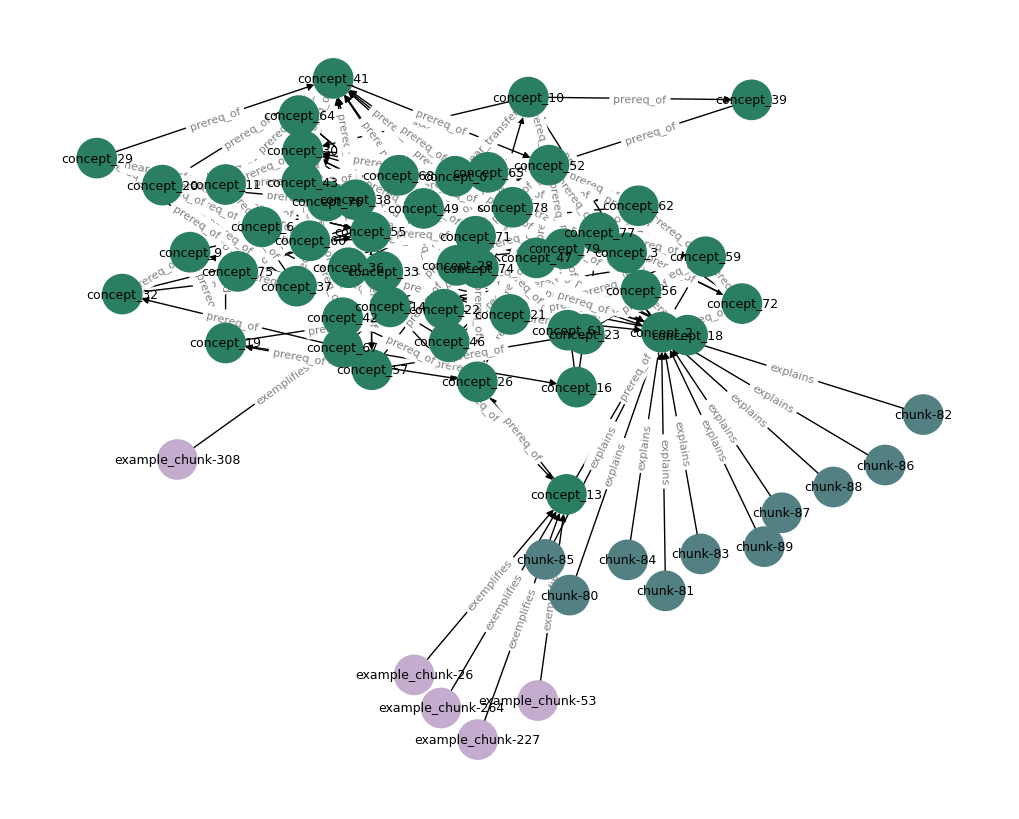

In [26]:
import matplotlib.pyplot as plt
sub = kg.subgraph_for_concepts([n for n,_ in kg.concepts_for_query("jensen inequality", top_k=4)], prereq_depth=1)
plt.figure(figsize=(10,8))
pos = nx.spring_layout(sub, seed=42)
node_colors = ["#2A7F62" if sub.nodes[n]['type']=="concept" else ("#538083" if sub.nodes[n]['type']=="resource" else "#C3ACCE") for n in sub.nodes()]
nx.draw(sub, pos, with_labels=True, node_color=node_colors, node_size=800, font_size=9)
edge_labels = { (u,v): d.get('type','') for u,v,d in sub.edges(data=True)}
nx.draw_networkx_edge_labels(sub, pos, edge_labels=edge_labels, font_color="gray", font_size=8)
plt.show()


In [27]:
def build_generation_prompt_for_subgraph(query, subgraph, ordered_prereq=True):
    """
    Build a hierarchical prompt:
      - list prerequisites first (simple -> complex)
      - include concise definitions and resource citations (node metadata)
      - ask LLM to answer step-by-step and cite resources
    """
    # find concept nodes and sort by indegree (prereq depth heuristic)
    concept_nodes = [n for n,d in subgraph.nodes(data=True) if d.get("type")=="concept"]
    # compute a simple score: indegree (more indegree -> more upstream)
    indeg = {n: subgraph.in_degree(n) for n in concept_nodes}
    ordered = sorted(concept_nodes, key=lambda x: indeg.get(x,0))  # lowest indegree first
    parts = [f"User query: {query}\n\n"]
    parts.append("Scaffolded concepts (simple -> complex):\n")
    for cid in ordered:
        node = subgraph.nodes[cid]
        parts.append(f"Concept: {node.get('title')}\nDefinition: {node.get('definitions')}\n")
        # attach top resource citations if any
        incoming = [(u,v,d) for u,v,d in subgraph.in_edges(cid, data=True) if d.get("type")=="explains"]
        if incoming:
            parts.append("References:\n")
            for u,v,d in incoming[:3]:
                rnode = subgraph.nodes[u]
                parts.append(f" - Resource: {str(rnode.get('metadata',{}).get('source',''))} (span={rnode.get('span','')})\n")
    parts.append("\nAnswer (use only the above material):\n")
    return "\n".join(parts)

# Example query
query = "Explain Jensen's inequality and where it's used"
cands = kg.concepts_for_query(query, top_k=4)
print("Candidates:", cands)
concept_ids = [cid for cid,_ in cands]
sub = kg.subgraph_for_concepts(concept_ids, prereq_depth=2)
prompt = build_generation_prompt_for_subgraph(query, sub)
print("Prompt length:", len(prompt))

# Call LLM
answer = ask_ollama(prompt)
print("\n=== GENERATED ANSWER ===\n")
print(answer[:4000])


Candidates: [('concept_20', 0.5519741773605347), ('concept_52', 0.5369470715522766), ('concept_62', 0.5231388807296753), ('concept_26', 0.5161898136138916)]
Prompt length: 26968

=== GENERATED ANSWER ===

The term "problem" refers to a specific task or challenge that students must solve to demonstrate their understanding and ability in natural language processing. This problem typically involves analyzing data, identifying patterns, and deriving insights from it. Students are expected to engage with practical examples and real-world scenarios, such as text generation tasks, to enhance their problem-solving skills and deepen their knowledge of the field.




C:\Users\Amrutha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


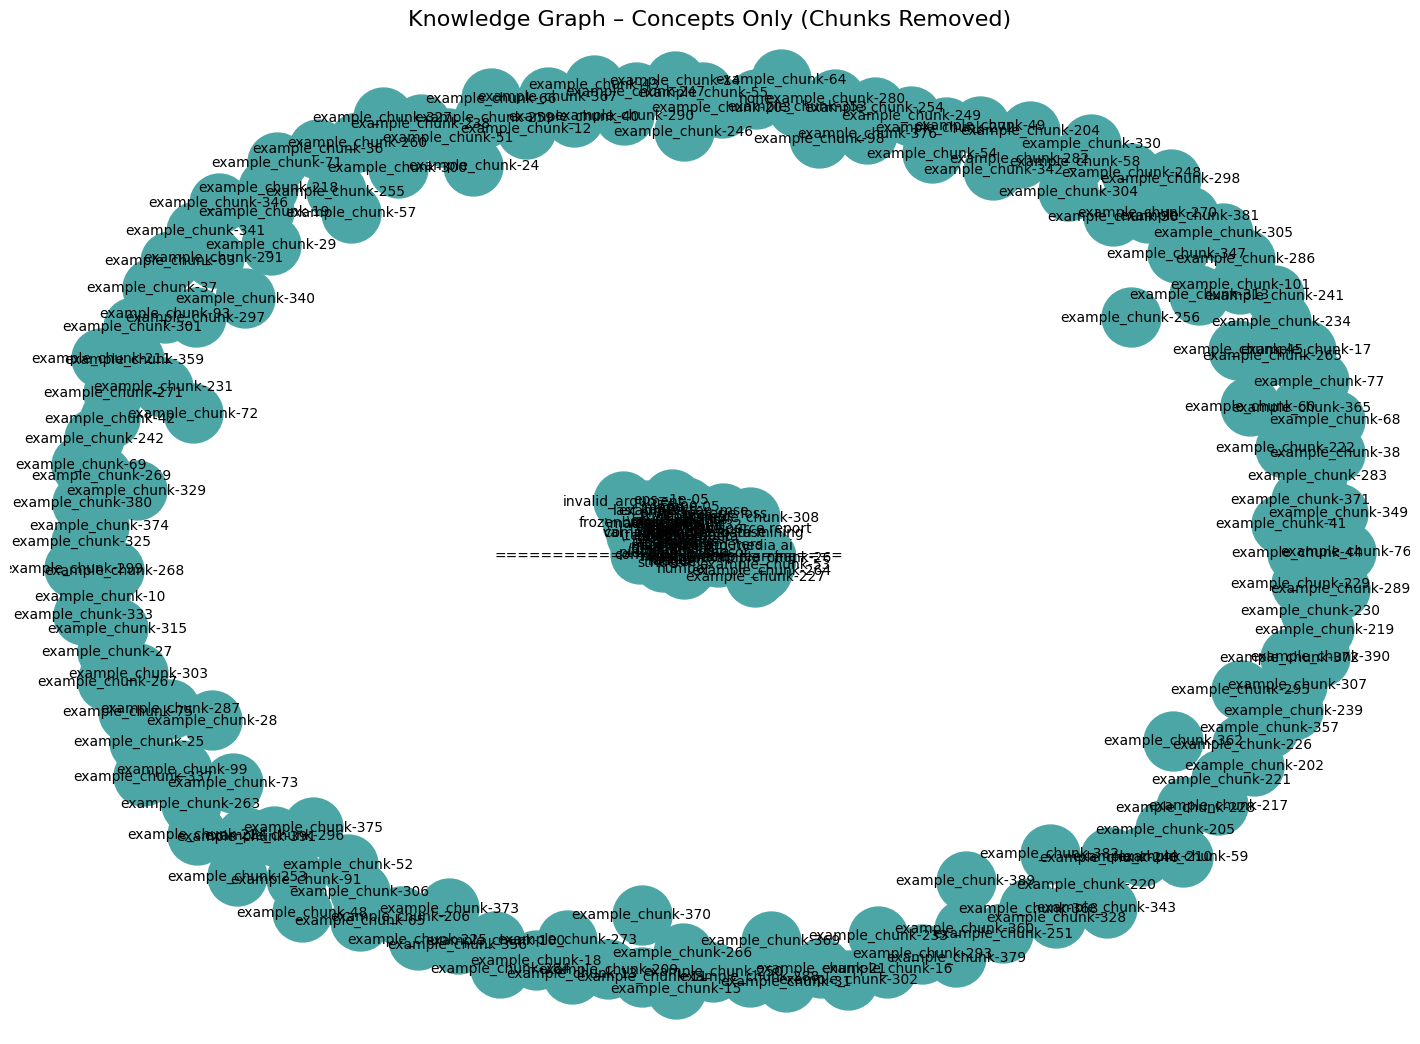

In [28]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(14, 10))

def is_chunk(node, data):
    node_id = str(node).lower()
    title = str(data.get("title", "")).lower()
    return node_id.startswith("chunk") or title.startswith("chunk")

# Filter out ALL chunk nodes
concept_nodes = [
    n for n, data in kg.G.nodes(data=True)
    if not is_chunk(n, data)
]

# Build subgraph
H = kg.G.subgraph(concept_nodes).copy()

# Layout
pos = nx.spring_layout(H, seed=42)

# Draw nodes
nx.draw(
    H,
    pos,
    with_labels=False,
    node_size=1800,
    node_color="#4da6a6",
    arrowsize=18,
)

# Labels = use title if exists
labels = {
    node: H.nodes[node].get("title", node)
    for node in H.nodes()
}
nx.draw_networkx_labels(H, pos, labels=labels, font_size=10)

# Edge labels
edge_labels = nx.get_edge_attributes(H, "relation")
nx.draw_networkx_edge_labels(
    H, pos,
    edge_labels=edge_labels,
    font_color="gray",
    font_size=8,
)

plt.title("Knowledge Graph – Concepts Only (Chunks Removed)", fontsize=16)
plt.axis("off")
plt.show()


In [29]:
# Save scraped URLs list
scraped_files = sorted(glob.glob(os.path.join(PAGE_DIR,"*.html")))
with open("data/ingested_urls.txt","w",encoding="utf-8") as f:
    for p in scraped_files:
        f.write(p+"\n")
print("Saved list of ingested pages to data/ingested_urls.txt")

# Save KG json already saved earlier. DB is in data/vector_db
print("Vector DB directory:", DB_DIR)
print("KG JSON:", "data/kg_course.json" if os.path.exists("data/kg_course.json") else "NOT CREATED")


Saved list of ingested pages to data/ingested_urls.txt
Vector DB directory: data/vector_db
KG JSON: data/kg_course.json
